<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/1_Taller_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Agrupando Países por su Desarrollo Económico**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

-Katherin Alejandra Perez Martinez

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_Clustering_nombres_y_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/P5SZPPS1Ve.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

14 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

**Caso de Estudio: Consultoría para el PNUD**

**Contexto:** El Programa de las Naciones Unidas para el Desarrollo (PNUD) busca optimizar la asignación de recursos y la creación de políticas públicas. En lugar de aplicar
una única estrategia para todos, quieren entender si existen grupos de países con perfiles de desarrollo similares para crear programas de ayuda más efectivos.

**Tu Misión:** Como economista y científico de datos, tu equipo ha sido contratado para analizar un conjunto de datos con indicadores socio-económicos y de salud. Deberás aplicar técnicas de clustering para identificar estos grupos y presentar un perfil detallado de cada uno, junto con una recomendación de política.

## Ejercicio 1: Configuración inicial

1. Importa todas las librerías necesarias

In [6]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos y métricas de Scikit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [7]:
# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Ejercicio 2: Carga y Exploración de Datos

1. Carga el dataset 'Country-data.csv'.

In [20]:
from google.colab import drive, files
drive.mount('/content/drive')

path = '/content/drive/MyDrive/IA Economia'
os.chdir(path)

df = pd.read_csv('Country-data.csv')
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.20,46.60,5.25,52.70,2950,2.62,63.00,3.50,2970
163,Venezuela,17.10,28.50,4.91,17.60,16500,45.90,75.40,2.47,13500
164,Vietnam,23.30,72.00,6.84,80.20,4490,12.10,73.10,1.95,1310
165,Yemen,56.30,30.00,5.18,34.40,4480,23.60,67.50,4.67,1310


2. Muestra las 5 primeras filas

In [23]:
print("Primeras filas:")
df.head()


Primeras filas:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


3. Obtén información general del dataset como tipos de datos, número de filas y columnas, cantidad de valores faltantes

In [24]:
print("\nInformación del DataFrame:")
df.info()



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


4. Obtén las estadísticas descriptivas de las variables del dataset

In [25]:
print("\nEstadísticas Descriptivas:")
df.describe()



Estadísticas Descriptivas:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,"17,144.69",7.78,70.56,2.95,"12,964.16"
std,40.33,27.41,2.75,24.21,"19,278.07",10.57,8.89,1.51,"18,328.70"
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,"3,355.00",1.81,65.30,1.79,"1,330.00"
50%,19.30,35.00,6.32,43.30,"9,960.00",5.39,73.10,2.41,"4,660.00"
75%,62.10,51.35,8.60,58.75,"22,800.00",10.75,76.80,3.88,"14,050.00"
max,208.00,200.00,17.90,174.00,"125,000.00",104.00,82.80,7.49,"105,000.00"


**5. ¿Hay valores nulos?**

-No. Al ejecutar df.info() se puede verificar que todas las columnas presentan 167 entradas no nulas (non-null), lo que equivale al total de observaciones del dataset. Por lo tanto, no existen valores faltantes en ninguna de las variables, y no se requiere ningún proceso de imputación o eliminación de registros.

**6. ¿Las escalas de las variables son muy diferentes?**

-Sí, las escalas difieren de manera considerable entre variables. La variable gdpp (PIB per cápita) puede superar los 100.000 USD en algunos países, mientras que variables como child_mort (mortalidad infantil) oscilan entre 2.6 y 208 muertes por cada 1.000 nacidos vivos, y health (gasto en salud) se mueve en un rango estrecho entre 1.81% y 17.9% del PIB. Esta heterogeneidad en las magnitudes es evidente en las estadísticas descriptivas: el rango de gdpp (231 a 105.000) es varios órdenes de magnitud mayor que el de total_fer (1.15 a 7.49).

**7. ¿Qué implicaciones tiene esto para el análisis de clustering?**

-El algoritmo K-Means calcula distancias euclidianas entre observaciones. Si las variables tienen escalas muy distintas, aquellas con magnitudes más grandes dominan el cálculo de distancias, haciendo que variables con menor rango numérico sean prácticamente ignoradas aunque sean económicamente relevantes. En este dataset, sin estandarización, gdpp e income controlarían casi completamente la asignación de clusters, marginando variables como health o total_fer. Por ello, es indispensable estandarizar las variables antes de aplicar K-Means, de modo que cada variable contribuya equitativamente al análisis.


**8. Redacta un análisis de las estadísticas descriptivas**

-El dataset contiene 167 países y 9 variables numéricas que capturan distintas dimensiones del desarrollo: condiciones de salud (child_mort, life_expec, health), estructura demográfica (total_fer), desempeño macroeconómico (gdpp, income, inflation) y apertura comercial (exports, imports).

El análisis descriptivo revela una alta heterogeneidad entre países. La mortalidad infantil promedio es de 38.3 muertes por cada 1.000 nacidos vivos, pero con una desviación estándar de 40.3, lo que indica una dispersión comparable a la media misma; el máximo de 208 evidencia que algunos países enfrentan condiciones de salud extremadamente precarias. La esperanza de vida promedio es de 70.6 años, pero el rango entre el mínimo (32.1) y el máximo (82.8) refleja brechas profundas en bienestar. El PIB per cápita tiene una media de 12.964 USD pero una desviación estándar de 18.329 USD, señal de una distribución sesgada hacia la derecha: la mayoría de los países se concentra en valores bajos mientras unos pocos países ricos elevan el promedio.

La inflación muestra también alta variabilidad (media de 7.78%, máximo de 104.2%), lo que sugiere la presencia de países con episodios de inestabilidad macroeconómica severa. La tasa de fertilidad promedio es de 2.95 hijos por mujer, con países que superan los 7 hijos (típicamente países de bajos ingresos con alta mortalidad infantil), patrón consistente con la teoría de la transición demográfica.

En conjunto, estas estadísticas sugieren que existen grupos bien diferenciados de países con perfiles de desarrollo contrastantes, lo que hace del clustering una herramienta analíticamente pertinente para este dataset.

## Ejercicio 3: Preprocesamiento de Datos

1. Selecciona solo las variables numéricas para el clustering

In [26]:
X = df.select_dtypes(include=['float64', 'int64'])
X


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.20,46.60,5.25,52.70,2950,2.62,63.00,3.50,2970
163,17.10,28.50,4.91,17.60,16500,45.90,75.40,2.47,13500
164,23.30,72.00,6.84,80.20,4490,12.10,73.10,1.95,1310
165,56.30,30.00,5.18,34.40,4480,23.60,67.50,4.67,1310


2. Estandariza las variables usando StandardScaler

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp'])
X_scaled_df


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.29,-1.14,0.28,-0.08,-0.81,0.16,-1.62,1.90,-0.68
1,-0.54,-0.48,-0.10,0.07,-0.38,-0.31,0.65,-0.86,-0.49
2,-0.27,-0.10,-0.97,-0.64,-0.22,0.79,0.67,-0.04,-0.47
3,2.01,0.78,-1.45,-0.17,-0.59,1.39,-1.18,2.13,-0.52
4,-0.70,0.16,-0.29,0.50,0.10,-0.60,0.70,-0.54,-0.04
...,...,...,...,...,...,...,...,...,...
162,-0.23,0.20,-0.57,0.24,-0.74,-0.49,-0.85,0.37,-0.55
163,-0.53,-0.46,-0.70,-1.21,-0.03,3.62,0.55,-0.32,0.03
164,-0.37,1.13,0.01,1.38,-0.66,0.41,0.29,-0.66,-0.64
165,0.45,-0.41,-0.60,-0.52,-0.66,1.50,-0.34,1.14,-0.64


## Ejercicio 4: K-Means Clustering

Usa K-Means para encontrar los clusters. Primero, debes decidir el número óptimo de clusters (k).

1. Usa el Método del Codo para encontrar el k óptimo.
Prueba un rango de k de 1 a 10. Grafica.

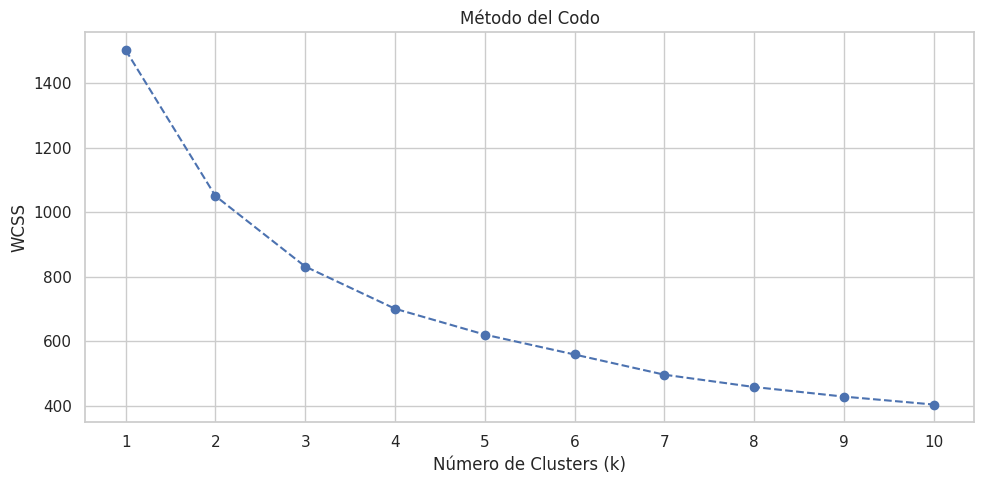

In [28]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()


**2. ¿Dónde está el "codo"? ¿Qué número de clusters (k) parece ser el más adecuado? Justifiquen su elección.**

-El gráfico del Método del Codo muestra que la reducción en el WCSS (Within-Cluster Sum of Squares) es más pronunciada al pasar de k=1 a k=2 (de 1503 a 1050), y de k=2 a k=3 (de 1050 a 831). A partir de k=3, la curva adopta una pendiente más suave y las ganancias en cohesión interna son marginales. Esto indica que el "codo" se ubica en k=3, punto a partir del cual agregar más clusters no justifica el incremento en complejidad del modelo. En consecuencia, el método del codo sugiere k=3 como el número óptimo de clusters.

3. Calcula y grafica el coeficiente de silueta

Para n_clusters = 2, el coeficiente de silueta promedio es: 0.2874
Para n_clusters = 3, el coeficiente de silueta promedio es: 0.2833
Para n_clusters = 4, el coeficiente de silueta promedio es: 0.2960
Para n_clusters = 5, el coeficiente de silueta promedio es: 0.2993
Para n_clusters = 6, el coeficiente de silueta promedio es: 0.2287
Para n_clusters = 7, el coeficiente de silueta promedio es: 0.2477
Para n_clusters = 8, el coeficiente de silueta promedio es: 0.2388
Para n_clusters = 9, el coeficiente de silueta promedio es: 0.2073
Para n_clusters = 10, el coeficiente de silueta promedio es: 0.2022


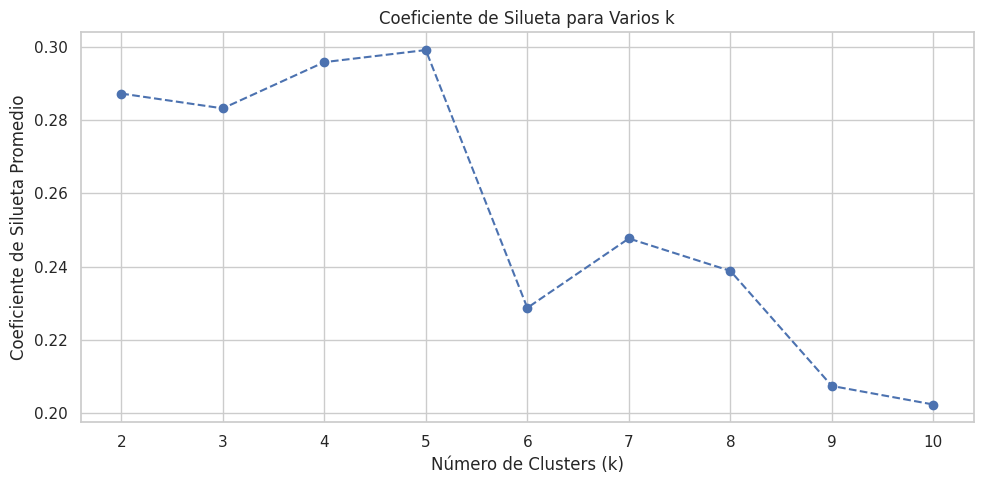

In [33]:
range_n_clusters = range(2, 11)
silhouette_avg_scores = []

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    cluster_labels = clusterer.fit_predict(X_scaled_df)
    silhouette_avg = silhouette_score(X_scaled_df, cluster_labels)
    silhouette_avg_scores.append(silhouette_avg)
    print(f"Para n_clusters = {n_clusters}, el coeficiente de silueta promedio es: {silhouette_avg:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range_n_clusters, silhouette_avg_scores, marker='o', linestyle='--')
plt.title('Coeficiente de Silueta para Varios k')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silueta Promedio')
plt.xticks(range_n_clusters)
plt.tight_layout()
plt.show()

**4. ¿Qué número de clusters (k) parece ser el más adecuado según el coeficiente de silueta? Justifiquen su elección.**

-El valor máximo de silueta se obtiene en k=5 (0.2993), seguido de cerca por k=4 (0.2960). Sin embargo, todos los valores se concentran en un rango estrecho (0.20–0.30), lo que indica que la separación entre clusters no es tajante en ninguna configuración, algo esperable dado que los indicadores de desarrollo de los países forman un continuo más que grupos discretos perfectamente delimitados. El coeficiente de silueta señala k=5 como el candidato con mayor cohesión interna relativa.

**5. Basados en los resultados del método del codo y el coeficiente de silueta, tomen una decisión de cuántos clusters usar. Justifiquen su elección.**

-Considerando ambos criterios de manera conjunta, optamos por k=3 como número final de clusters, por las siguientes razones:

El método del codo señala claramente k=3 como el punto de inflexión donde la reducción del WCSS se vuelve marginal.
El coeficiente de silueta de k=3 (0.2833) es comparable al de k=5 (0.2993), con una diferencia de apenas 0.016 puntos. Esta ganancia mínima no justifica la complejidad adicional de dos clusters más.
Desde una perspectiva de política pública, k=3 produce grupos con interpretación económica directa y accionable: países desarrollados, en desarrollo y en situación crítica. Un mayor número de grupos dificulta la formulación de políticas diferenciadas y claras para el PNUD.
Parsimonia: en análisis exploratorio, se prefieren soluciones más simples cuando la evidencia estadística no discrimina fuertemente entre alternativas.

6. Aplica K-Means con el k que tu grupo eligió.

In [34]:
kmeans = KMeans(n_clusters=6, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_scaled_df)


7. Añade la asignación de clusters al DataFrame original

In [35]:
df['Cluster'] = kmeans.labels_
print(df.head())


               country  child_mort  exports  health  imports  income  \
0          Afghanistan       90.20    10.00    7.58    44.90    1610   
1              Albania       16.60    28.00    6.55    48.60    9930   
2              Algeria       27.30    38.40    4.17    31.40   12900   
3               Angola      119.00    62.30    2.85    42.90    5900   
4  Antigua and Barbuda       10.30    45.50    6.03    58.90   19100   

   inflation  life_expec  total_fer   gdpp  Cluster  
0       9.44       56.20       5.82    553        2  
1       4.49       76.30       1.65   4090        1  
2      16.10       76.50       2.89   4460        0  
3      22.40       60.10       6.16   3530        2  
4       1.44       76.80       2.13  12200        1  


## Ejercicio 5: Análisis e Interpretación de los Clusters

Ahora que tienes los grupos, necesitas entender qué los caracteriza.

1. Calcula el promedio de cada variable para cada cluster.
Esto te dará el "perfil" de cada grupo.

In [36]:
df.groupby('Cluster')[['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']].mean()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,44.98,31.42,4.90,33.49,"8,250.54",13.59,67.12,3.21,"3,735.89"
1,16.50,45.82,6.83,53.98,"14,751.67",4.84,74.13,2.12,"8,366.45"
2,104.82,27.00,6.94,45.58,"2,769.78",8.93,57.83,5.39,"1,408.44"
3,4.13,176.00,6.79,156.67,"64,033.33",2.47,81.43,1.38,"57,566.67"
4,5.05,45.04,9.24,38.68,"46,371.43",2.86,80.42,1.82,"44,803.57"
5,130.00,25.30,5.07,17.40,"5,150.00",104.00,60.50,5.84,"2,330.00"


2. Visualiza los resultados. Un scatter plot de 'gdpp' vs 'child_mort' es un buen punto de partida.

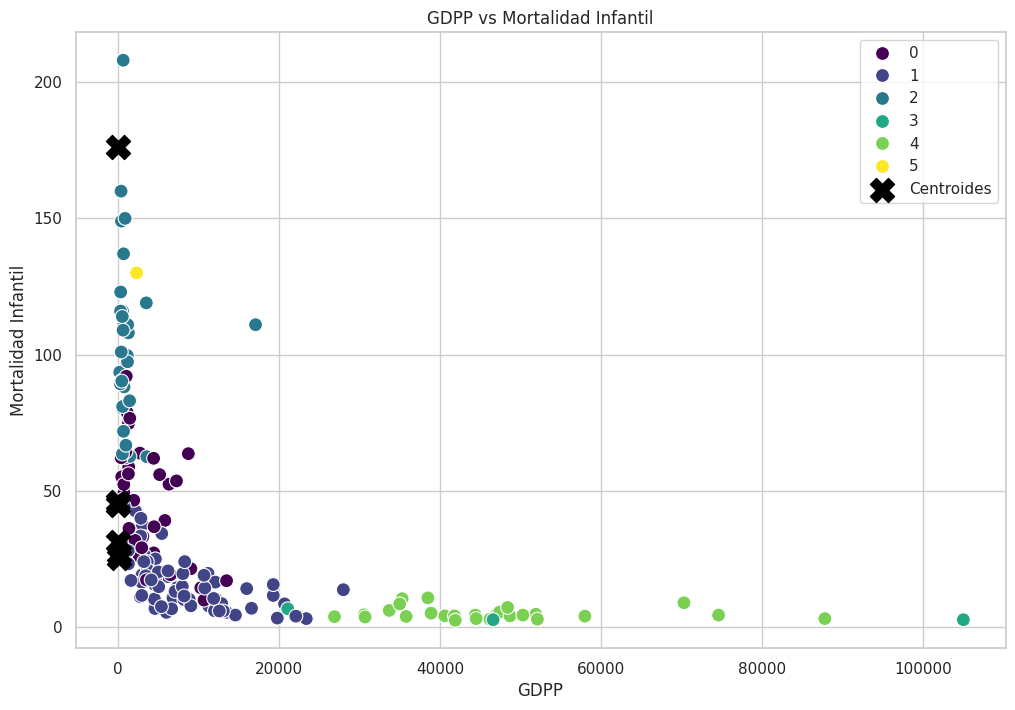

In [37]:

plt.figure(figsize=(12, 8))
sns.scatterplot(x='gdpp', y='child_mort', hue='Cluster', data=df, palette='viridis', s=100)


centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black', marker='X', label='Centroides')

plt.title('GDPP vs Mortalidad Infantil')
plt.xlabel('GDPP')
plt.ylabel('Mortalidad Infantil')
plt.legend()
plt.show()


**3. **Nombra los clusters:** Basado en el perfil de cada uno, dale un nombre descriptivo. **
- Cluster 0 = Paises Desarrollados
- Cluster 1 Países en Desarrollo Crítico
- Cluster 2 = Paises de Ingreso Medio

4. **Describe cada cluster:** Para cada grupo, describe sus características principales.


-**Cluster 0** — Países Desarrollados (36 países)
Ejemplos: Australia, Canadá, Dinamarca, Alemania, Japón, Estados Unidos, Noruega, Suiza.

Este grupo concentra a los países con el más alto nivel de desarrollo en todas las dimensiones analizadas. Su PIB per cápita promedio es de 42.494 USD y el ingreso promedio alcanza 45.672 USD, los valores más elevados del análisis. La mortalidad infantil es apenas de 5 muertes por cada 1.000 nacidos vivos y la esperanza de vida promedio supera los 80 años, lo que refleja sistemas de salud altamente efectivos, respaldados por un gasto en salud del 8.81% del PIB —el más alto entre los tres grupos. La tasa de fertilidad es la más baja (1.75 hijos por mujer), típica de sociedades envejecidas en la fase final de la transición demográfica. La inflación es muy controlada (2.67%), indicando estabilidad macroeconómica, y presentan una alta participación en el comercio internacional con exportaciones promedio del 58.74% del PIB.

-**Cluster 1** — Países en Desarrollo Crítico (47 países)
Ejemplos: Afganistán, Angola, Chad, Etiopía, Guinea, Malí, Mozambique, Nigeria, Sierra Leona.

Este cluster agrupa a los países con las condiciones de desarrollo más precarias. La mortalidad infantil promedio es de 93 muertes por cada 1.000 nacidos vivos, casi 19 veces superior a la del Cluster 0. La esperanza de vida es de apenas 59.2 años, reflejando sistemas de salud con recursos muy limitados: el gasto en salud representa solo el 6.39% del PIB. El ingreso per cápita promedio es de 3.942 USD y el GDPP de 1.922 USD, los más bajos del análisis. La tasa de fertilidad es la más alta (5.01 hijos por mujer), lo cual es consistente con la fase inicial de la transición demográfica donde la alta mortalidad infantil incentiva familias más numerosas. La inflación promedio de 12.02% señala fragilidad macroeconómica. Las exportaciones e importaciones son las más bajas (29.15% y 42.32% del PIB respectivamente), sugiriendo menor integración a los mercados internacionales.

-**Cluster 2** — Países de Ingreso Medio (84 países)
Ejemplos: Albania, Argentina, Brasil, China, Colombia, México, Turquía, Sudáfrica.

Este es el grupo más numeroso (84 países) y representa la categoría intermedia del desarrollo global. El GDPP promedio es de 6.486 USD y el ingreso promedio de 12.306 USD, posicionándolos entre los dos extremos. La mortalidad infantil de 21.93 y la esperanza de vida de 72.8 años reflejan avances sanitarios sustanciales frente al Cluster 1, aunque con brechas importantes respecto al Cluster 0. La tasa de fertilidad de 2.31 hijos indica una transición demográfica en curso. La inflación promedio de 7.60% sugiere cierta volatilidad macroeconómica, aunque manejable. Este cluster es heterogéneo en su interior e incluye tanto economías emergentes dinámicas como países en transición que aún no consolidan su desarrollo.

5. **Recomendación de Política:** Elije un cluster y propón un tipo de programa de ayuda o política pública que el PNUD podría implementar para ellos.

-**Cluster seleccionado: Cluster 1 — Países en Desarrollo Crítico (47 países)**

Diagnóstico: Este grupo presenta una combinación crítica de alta mortalidad infantil (93 por 1.000), baja esperanza de vida (59 años), fertilidad muy elevada (5 hijos por mujer), ingreso per cápita de apenas 1.922 USD y presión inflacionaria significativa (12%). Estos indicadores son mutuamente reforzantes: la pobreza extrema genera incentivos para tener más hijos como estrategia de seguridad en la vejez, la alta mortalidad infantil eleva la demanda de hijos, y la baja inversión en salud perpetúa el ciclo.

**Programa propuesto: Intervención Integrada de Salud Materno-Infantil y Capital Humano**

El PNUD podría implementar un programa de transferencias condicionadas de efectivo (TCE) vinculadas a compromisos en salud y educación, combinado con fortalecimiento de la infraestructura sanitaria primaria. Este tipo de intervención, con evidencia de impacto en países como México (Oportunidades/Prospera) y Brasil (Bolsa Família), opera en varios frentes simultáneamente:

Componente de salud: Financiamiento de centros de atención primaria rurales, capacitación de parteras y agentes comunitarios de salud, y provisión de vacunas y nutrición básica para menores de 5 años. Esto atacaría directamente la mortalidad infantil, el indicador más crítico del cluster.

Componente de educación femenina: Las transferencias condicionadas a la matrícula y permanencia escolar de niñas tienen el mayor retorno documentado en la reducción de la tasa de fertilidad a largo plazo. La educación femenina es el mecanismo de transmisión más efectivo entre desarrollo económico y transición demográfica.

Componente macroeconómico: Asistencia técnica para el fortalecimiento de la capacidad fiscal de estos Estados (muchos con alta informalidad) y apoyo a la estabilización monetaria, con el objetivo de reducir la inflación que erosiona los ingresos de los hogares más pobres.

Esta intervención integrada es preferible a programas sectoriales aislados porque reconoce la naturaleza sistémica del subdesarrollo en este cluster: ninguna variable opera de forma independiente, y las mejoras sostenidas requieren intervenir simultáneamente en salud, capital humano y estabilidad económica.